Plot population pyramid for Malaysia from state data

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

population_data = pd.read_csv("population_state.csv")
population_data.head()

,state,date,sex,age,ethnicity,population
0,Johor,1970-01-01,both,overall,overall,1325.6
1,Johor,1970-01-01,both,0-4,overall,210.1
2,Johor,1970-01-01,both,5-9,overall,215.7
3,Johor,1970-01-01,both,10-14,overall,192.2
4,Johor,1970-01-01,both,15-19,overall,152.8


In [140]:
population_data["year"] = pd.to_datetime(population_data["date"]).dt.year
population_data.head()

,state,date,sex,age,ethnicity,population,year
0,Johor,1970-01-01,both,overall,overall,1325.6,1970
1,Johor,1970-01-01,both,0-4,overall,210.1,1970
2,Johor,1970-01-01,both,5-9,overall,215.7,1970
3,Johor,1970-01-01,both,10-14,overall,192.2,1970
4,Johor,1970-01-01,both,15-19,overall,152.8,1970


Plot for 1970

In [141]:
population_data_pyramid = population_data[
    (population_data["year"] == 1970) &
    (population_data["age"] != "overall") &
    (population_data["ethnicity"] == "overall") &
    (population_data["sex"] != "both")
][["age", "sex", "population"]].copy()

In [142]:
population_data_pyramid = population_data_pyramid.groupby(["age", "sex"], as_index = False)['population'].sum()
population_data_pyramid

,age,sex,population
0,0-4,female,833.1
1,0-4,male,869.2
2,10-14,female,714.6
3,10-14,male,740.2
4,15-19,female,599.7
5,15-19,male,597.9
6,20-24,female,461.2
7,20-24,male,460.4
8,25-29,female,344.4
9,25-29,male,347.9


In [143]:
population_data_pyramid["age_order"] = population_data_pyramid["age"].str.extract(r"(\d+)").astype(int)
population_data_pyramid = population_data_pyramid.sort_values("age_order")
population_data_pyramid

,age,sex,population,age_order
0,0-4,female,833.1,0
1,0-4,male,869.2,0
18,5-9,female,826.5,5
19,5-9,male,863.6,5
2,10-14,female,714.6,10
3,10-14,male,740.2,10
4,15-19,female,599.7,15
5,15-19,male,597.9,15
6,20-24,female,461.2,20
7,20-24,male,460.4,20


In [144]:
age_order = population_data_pyramid["age"].unique()
population_data_pyramid_table = population_data_pyramid.pivot_table(
                                    index = "age", columns="sex", values="population").fillna(0)
population_data_pyramid_table = population_data_pyramid_table.reindex(age_order)
population_data_pyramid_table

sex,female,male
age,,
0-4,833.1,869.2
5-9,826.5,863.6
10-14,714.6,740.2
15-19,599.7,597.9
20-24,461.2,460.4
25-29,344.4,347.9
30-34,325.9,333.4
35-39,262.9,258.8
40-44,226.5,231.2


In [145]:
population_data_pyramid_table["male"] = -population_data_pyramid_table["male"]
population_data_pyramid_table

sex,female,male
age,,
0-4,833.1,-869.2
5-9,826.5,-863.6
10-14,714.6,-740.2
15-19,599.7,-597.9
20-24,461.2,-460.4
25-29,344.4,-347.9
30-34,325.9,-333.4
35-39,262.9,-258.8
40-44,226.5,-231.2


C:\Users\Acer\AppData\Local\Temp\ipykernel_15496\243523131.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


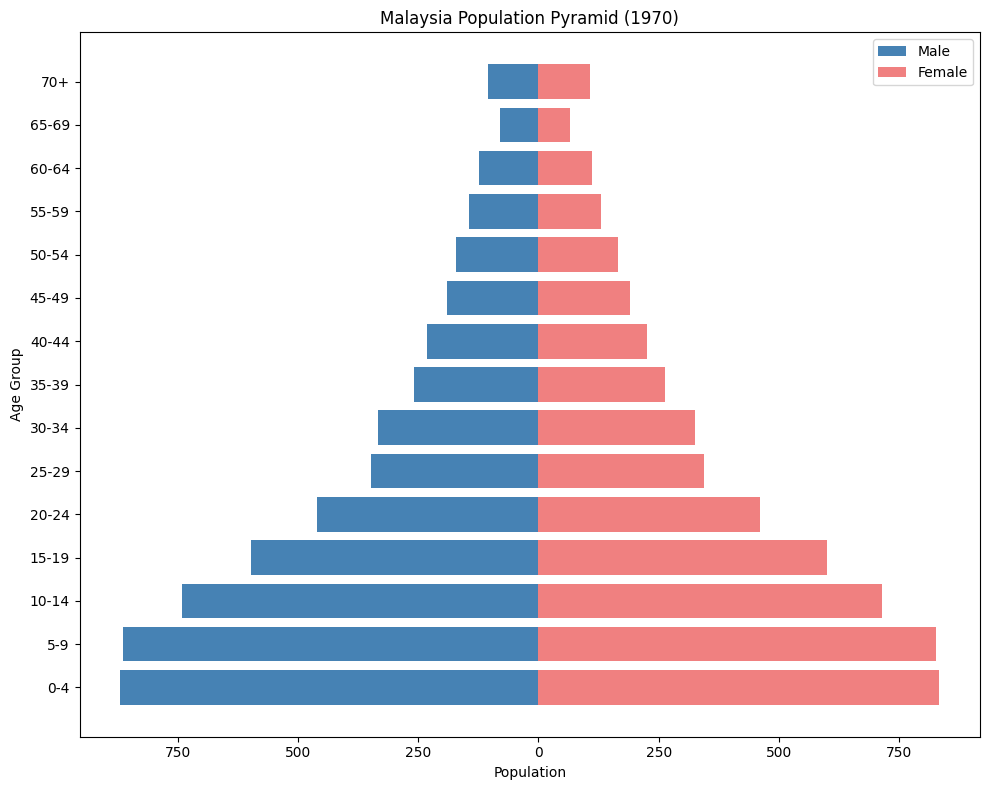

In [146]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["male"], color="steelblue", label="Male")
ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["female"], color="lightcoral", label="Female")

ax.set_title("Malaysia Population Pyramid (1970)")
ax.set_xlabel("Population")
ax.set_ylabel("Age Group")

# Make x-axis labels positive
xticks = ax.get_xticks()
ax.set_xticklabels([abs(int(x)) for x in xticks])

ax.legend()
plt.tight_layout()
plt.show()

Plot for any year

C:\Users\Acer\AppData\Local\Temp\ipykernel_15496\3255901338.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


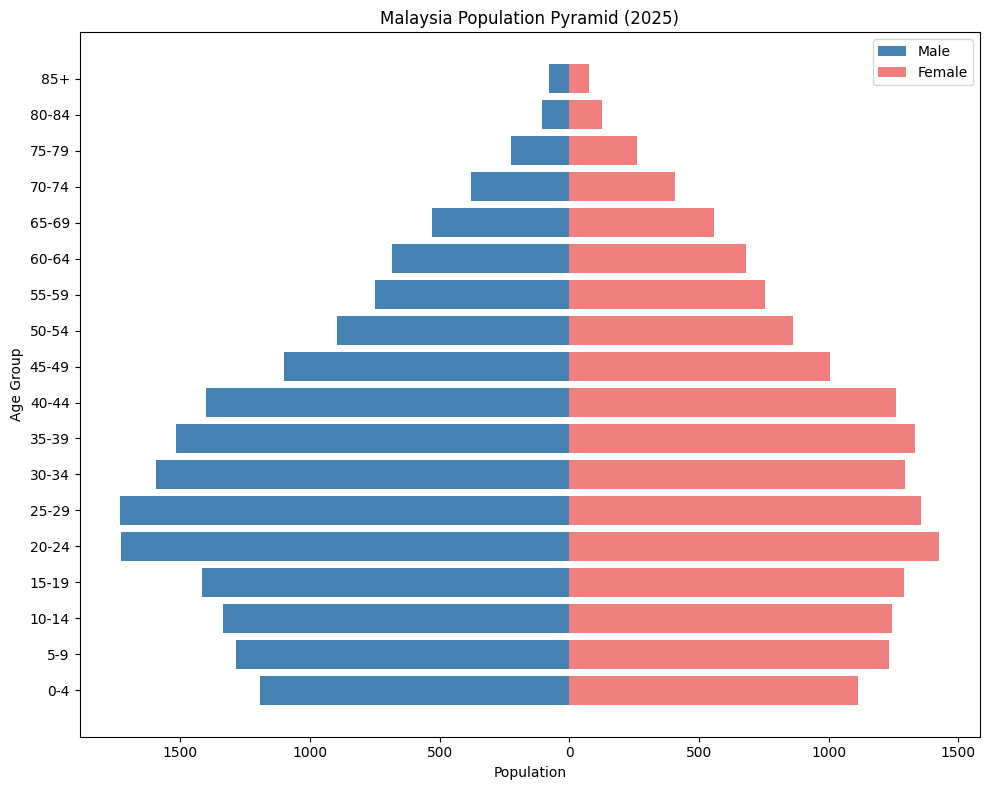

In [148]:
def data_pyramid_malaysia_by_year(year):
    population_data_pyramid = population_data[
        (population_data["year"] == year) &
        (population_data["age"] != "overall") &
        (population_data["ethnicity"] == "overall") &
        (population_data["sex"] != "both")
    ][["age", "sex", "population"]].copy()

    population_data_pyramid = population_data_pyramid.groupby(["age", "sex"], as_index = False)['population'].sum()

    population_data_pyramid["age_order"] = population_data_pyramid["age"].str.extract(r"(\d+)").astype(int)
    population_data_pyramid = population_data_pyramid.sort_values("age_order")

    age_order = population_data_pyramid["age"].unique()
    population_data_pyramid_table = population_data_pyramid.pivot_table(
                                    index = "age", columns="sex", values="population").fillna(0)
    population_data_pyramid_table = population_data_pyramid_table.reindex(age_order)
    
    return population_data_pyramid_table

def plot_malaysia_population_pyramid_year(year):
    population_data_pyramid_table = data_pyramid_malaysia_by_year(year)
    population_data_pyramid_table["male"] = -population_data_pyramid_table["male"]
    
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["male"], color="steelblue", label="Male")
    ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["female"], color="lightcoral", label="Female")

    ax.set_title(f"Malaysia Population Pyramid ({year})")
    ax.set_xlabel("Population")
    ax.set_ylabel("Age Group")

    xticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(x)) for x in xticks])

    ax.legend()
    plt.tight_layout()
    plt.show()

plot_malaysia_population_pyramid_year(2025)